## Competition02 Bank
### 1. コンペ概要 
銀行の顧客情報をもとに、定期預金キャンペーンに反応するかどうかを予測する分類問題である。  
顧客の年齢や職業、婚姻状況、過去のキャンペーン結果などの情報から、定期預金を申し込むかどうかを予測する。

### 2. 目的  
- EDAを行い、データの特徴を理解する 
- 適切な前処理や特徴量作成を行い、機械学習モデルを作成して予測精度の向上を目指す  
- Titanicで学んだ分析の流れを自分で考えながら実践する

### 3. 使用ライブラリ  
- pandas  
- numpy  
- matplotlib  
- scikit-learn

### 4. データ読み込み

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
train = pd.read_csv("../data/train.csv")

### 5. EDA

In [8]:
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1,39,blue-collar,married,secondary,no,1756,yes,no,cellular,3,apr,939,1,-1,0,unknown,1
1,2,51,entrepreneur,married,primary,no,1443,no,no,cellular,18,feb,172,10,-1,0,unknown,1
2,3,36,management,single,tertiary,no,436,no,no,cellular,13,apr,567,1,595,2,failure,1
3,4,63,retired,married,secondary,no,474,no,no,cellular,25,jan,423,1,-1,0,unknown,1
4,5,31,management,single,tertiary,no,354,no,no,cellular,30,apr,502,1,9,2,success,1


- age 年齢  
- job 職種  
- marital 未婚/既婚  
- education 教育水準  
- default 債務不履行かあるか(yes,no)  
- balance 年間平均残高(€)  
- housing 住宅ローン(yes,no)  
- loan 個人ローン(yes,no)  
- contact 連絡方法  
- day 最終接触日  
- month 最終接触月  
- duration 最終接触時間(秒)  
- compaign 現キャンペーンにおける接触回数
- pdays 経過日数:前キャンペン接触後の日数  
- previous 接触実績:現キャンペーン以前までに顧客に接触した回数  
- poutcome 前回キャンペーンの成果  
- y 定額預金申し込み有無(1:有,0:無)  
  

現キャンペーンが定額預金に関するものでその結果がy

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 27128 entries, 0 to 27127
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         27128 non-null  int64
 1   age        27128 non-null  int64
 2   job        27128 non-null  str  
 3   marital    27128 non-null  str  
 4   education  27128 non-null  str  
 5   default    27128 non-null  str  
 6   balance    27128 non-null  int64
 7   housing    27128 non-null  str  
 8   loan       27128 non-null  str  
 9   contact    27128 non-null  str  
 10  day        27128 non-null  int64
 11  month      27128 non-null  str  
 12  duration   27128 non-null  int64
 13  campaign   27128 non-null  int64
 14  pdays      27128 non-null  int64
 15  previous   27128 non-null  int64
 16  poutcome   27128 non-null  str  
 17  y          27128 non-null  int64
dtypes: int64(9), str(9)
memory usage: 3.7 MB


In [5]:
train.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

- 27128人分のデータがある  
- 欠損値は存在しない  
- 数値データと文字データが混在している  
- 文字データは機械学習の前処理で数値に変換する必要がある

In [6]:
train.describe()

,id,age,balance,day,duration,campaign,pdays,previous,y
count,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000
mean,13564.500000,40.951010,1355.800870,15.806215,260.711295,2.751769,40.528052,0.579733,0.117001
std,7831.323388,10.608542,3003.305272,8.337904,260.091727,3.126594,100.382462,2.503653,0.321427
min,1.000000,18.000000,-6847.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,6782.750000,33.000000,72.000000,8.000000,104.000000,1.000000,-1.000000,0.000000,0.000000
50%,13564.500000,39.000000,449.000000,16.000000,182.000000,2.000000,-1.000000,0.000000,0.000000
75%,20346.250000,48.000000,1428.000000,21.000000,323.000000,3.000000,-1.000000,0.000000,0.000000
max,27128.000000,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


#### 仮説

①previous・poutcome  
前回キャンペーンの接触数とその結果が今回にも影響しそう。前回成功している人、接触している人の方が申し込む可能性が高そう。  
②balance  
残高が高い人ほど申し込みそう。お金に余裕がある人ほど申し込みそう。  
③job・education  
職業や教育水準によって収入や資産状況が異なるため、申し込み率にも差がある可能性がある。
④duration  
最終接触時間が長い人の方が申し込みそう。
⑤default  
債務不履行がある人は申し込みにくそう。  
⑥age  
若い人と定年後の人では、貯蓄への考え方が違う可能性がある。

#### 仮説の検証

##### 目的変数の確認

In [9]:
train["y"].value_counts()

y
0    23954
1     3174
Name: count, dtype: int64

value_counts()...個数が集計される

In [11]:
train["y"].value_counts(normalize=True) * 100

y
0    88.299912
1    11.700088
Name: proportion, dtype: float64

normalize=True...割合で計算する  
*100で%になる

そもそも申し込んでいる人が少ないことがわかる。88%が申し込んでおらず、12%の人が申し込んでいる。

##### ①poutcome(前回キャンペーンの成果)

In [12]:
train.groupby("poutcome")["y"].mean()

poutcome
failure    0.131694
other      0.154052
success    0.647856
unknown    0.091919
Name: y, dtype: float64

前回キャンペーンで成功している人の方が申し込んでいることがわかる。

##### ①previous(接触実績)

<Axes: title={'center': 'Previous distribution for y = 1'}, xlabel='Previous', ylabel='Count'>

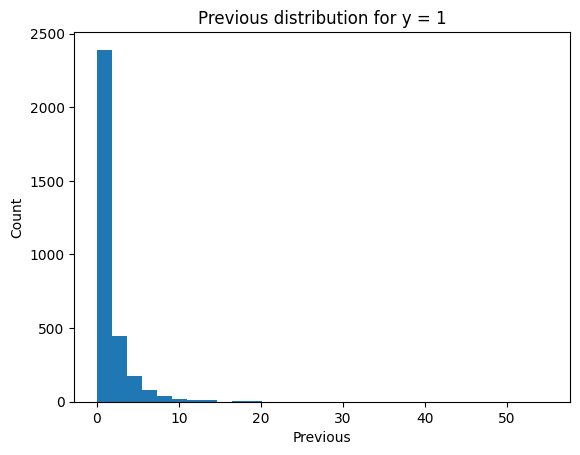

In [19]:
train[train["y"] == 1]["previous"].plot(
  kind = "hist",
  bins = 30,
  title = "Previous distribution for y = 1",
  xlabel = "Previous",
  ylabel = "Count",
)

In [42]:
train[train["y"] == 1]["previous"].value_counts().sort_index()

previous
0     2034
1      356
2      270
3      176
4      109
5       65
6       46
7       31
8       26
9       12
10      16
11       8
12       5
13       6
14       4
15       1
17       2
19       2
20       1
21       1
22       1
29       1
55       1
Name: count, dtype: int64

In [40]:
train[train["y"] == 1]["previous"].value_counts(normalize=True).sort_index()

previous
0     0.640832
1     0.112161
2     0.085066
3     0.055451
4     0.034342
5     0.020479
6     0.014493
7     0.009767
8     0.008192
9     0.003781
10    0.005041
11    0.002520
12    0.001575
13    0.001890
14    0.001260
15    0.000315
17    0.000630
19    0.000630
20    0.000315
21    0.000315
22    0.000315
29    0.000315
55    0.000315
Name: proportion, dtype: float64

接触回数0:2034 64%  
接触回数1:356 11%  
接触回数2:270 9%  
接触回数3:176 6%  
接触回数4:109 3%  
9回以降ほぼ0%

<Axes: title={'center': 'Previous distribution for y = 0'}, xlabel='Previous', ylabel='Count'>

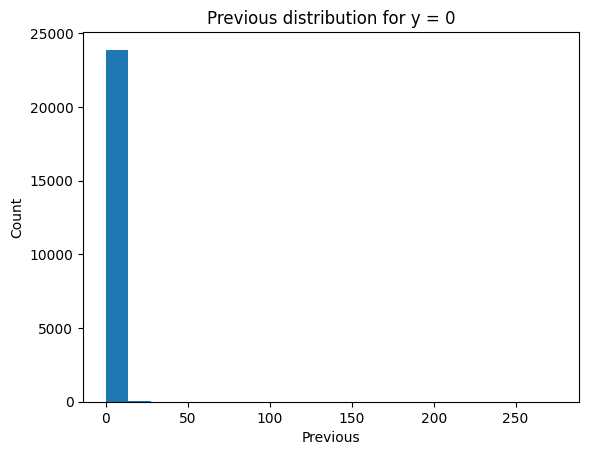

In [23]:
train[train["y"] == 0]["previous"].plot(
  kind = "hist",
  bins = 20,
  title = "Previous distribution for y = 0",
  xlabel = "Previous",
  ylabel = "Count",
)

In [39]:
train[train["y"] == 0]["previous"].value_counts().sort_index()

previous
0      20112
1       1328
2       1003
3        513
4        336
5        199
6        120
7         86
8         56
9         38
10        29
11        23
12        19
13        21
14         8
15        14
16         6
17         6
18         2
19         6
20         4
21         2
22         3
23         3
24         2
25         3
27         4
28         1
29         2
38         1
40         1
41         1
51         1
275        1
Name: count, dtype: int64

In [41]:
train[train["y"] == 0]["previous"].value_counts(normalize=True).sort_index()

previous
0      0.839609
1      0.055440
2      0.041872
3      0.021416
4      0.014027
5      0.008308
6      0.005010
7      0.003590
8      0.002338
9      0.001586
10     0.001211
11     0.000960
12     0.000793
13     0.000877
14     0.000334
15     0.000584
16     0.000250
17     0.000250
18     0.000083
19     0.000250
20     0.000167
21     0.000083
22     0.000125
23     0.000125
24     0.000083
25     0.000125
27     0.000167
28     0.000042
29     0.000083
38     0.000042
40     0.000042
41     0.000042
51     0.000042
275    0.000042
Name: proportion, dtype: float64

接触回数0:20112 84%  
接触回数1:1328 6%  
接触回数2:1003 4%  
接触回数3:513 2%  
接触回数4:336 1%  
7回以降ほぼ0%

previousはあまりyに関係していなそう。ほとんどが回数が0回なのと、申し込んでいなくても申し込んでいても接触回数が少ない方が割合が高いことからあまり関係していなそう。

##### ②balance(年間平均残高)

In [51]:
train.groupby("y")["balance"].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,23954.0,1305.702805,2996.408734,-6847.0,58.0,417.0,1344.00,102127.0
1,3174.0,1733.888154,3028.712596,-3058.0,215.0,718.5,2148.25,52587.0


<Axes: title={'center': 'balance distribution'}, xlabel='balance', ylabel='Count'>

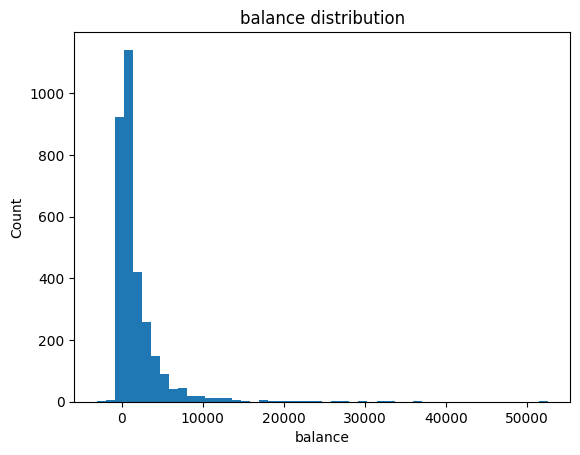

In [49]:
train[train["y"] == 1]["balance"].plot(
  kind = "hist",
  bins = 50,
  title = "balance distribution",
  xlabel = "balance",
  ylabel = "Count",
)

<Axes: title={'center': 'balance distribution'}, xlabel='balance', ylabel='Count'>

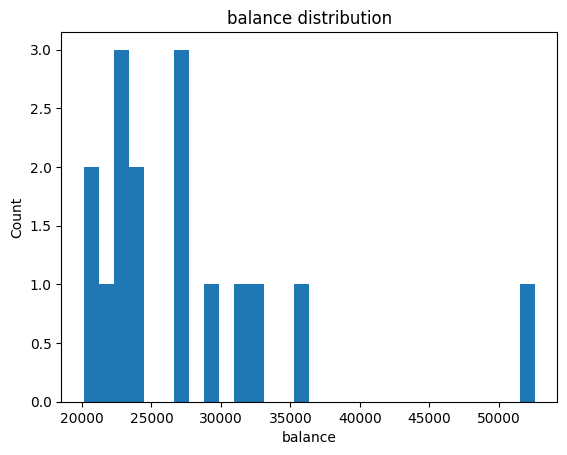

In [58]:
train[(train["y"] == 1) & (train["balance"] > 20000)]["balance"].plot(
  kind = "hist",
  bins = 30,
  title = "balance distribution",
  xlabel = "balance",
  ylabel = "Count",
)

<Axes: title={'center': 'balance distribution'}, xlabel='balance', ylabel='Count'>

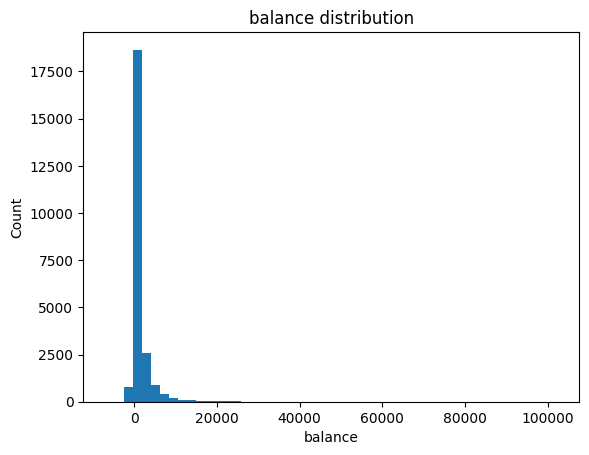

In [50]:
train[train["y"] == 0]["balance"].plot(
  kind = "hist",
  bins = 50,
  title = "balance distribution",
  xlabel = "balance",
  ylabel = "Count",
)

<Axes: title={'center': 'balance distribution'}, xlabel='balance', ylabel='Count'>

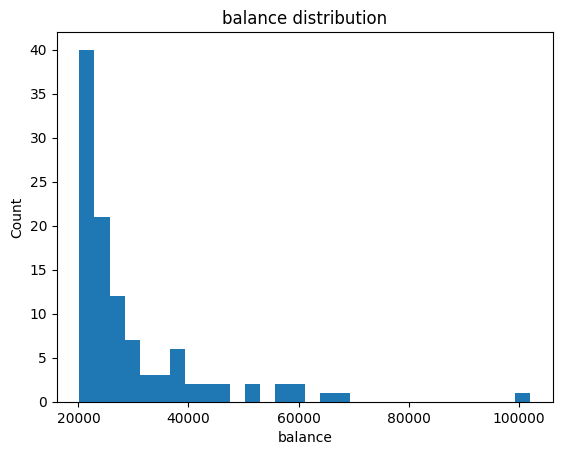

In [56]:
train[(train["y"] == 0) & (train["balance"] > 20000)]["balance"].plot(
  kind = "hist",
  bins = 30,
  title = "balance distribution",
  xlabel = "balance",
  ylabel = "Count",
)

In [61]:
import seaborn as sns

In [ ]:
sns.histplot()